Saving PRSA_Data_Shunyi_20130301-20170228.csv to PRSA_Data_Shunyi_20130301-20170228 (1).csv
Dataset Shape: (35064, 18)
First 5 Rows:
   No  year  month  day  hour  PM2.5  PM10  SO2  NO2     CO    O3  TEMP  \
0   1  2013      3    1     0    3.0   6.0  3.0  8.0  300.0  44.0  -0.9   
1   2  2013      3    1     1   12.0  12.0  3.0  7.0  300.0  47.0  -1.1   
2   3  2013      3    1     2   14.0  14.0  NaN  7.0  200.0  22.0  -1.7   
3   4  2013      3    1     3   12.0  12.0  3.0  5.0    NaN   NaN  -2.1   
4   5  2013      3    1     4   12.0  12.0  3.0  NaN  200.0  11.0  -2.4   

     PRES  DEWP  RAIN  wd  WSPM station  
0  1025.8 -20.5   0.0  NW   9.3  Shunyi  
1  1026.1 -21.3   0.0  NW   9.4  Shunyi  
2  1026.2 -23.0   0.0  NW   8.6  Shunyi  
3  1027.3 -23.3   0.0  NW   6.6  Shunyi  
4  1027.7 -22.9   0.0  NW   4.5  Shunyi  
Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype

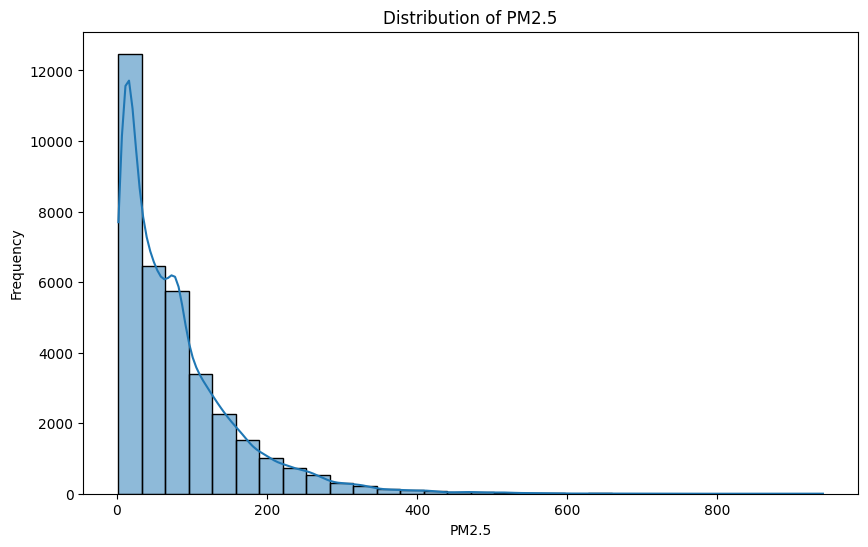

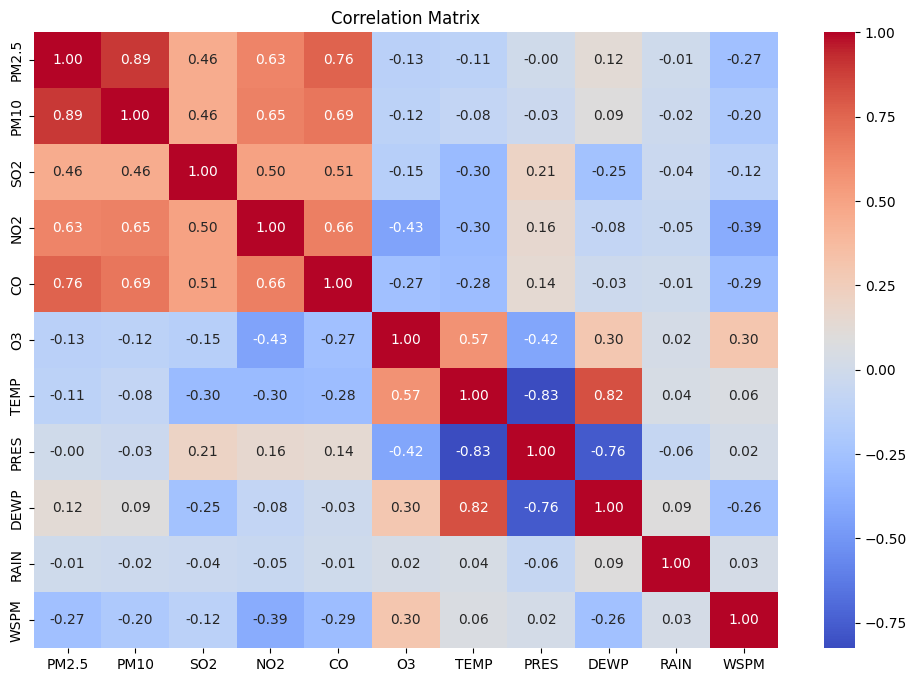

Variables Most Correlated with PM2.5:
PM2.5    1.000000
PM10     0.894480
CO       0.758956
NO2      0.633953
SO2      0.457087
DEWP     0.123126
PRES    -0.002340
RAIN    -0.006600
TEMP    -0.114435
O3      -0.132123
WSPM    -0.266601
Name: PM2.5, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
from google.colab import files
files.upload() # This will prompt you to upload the 'data.csv' file
file_path = 'PRSA_Data_Shunyi_20130301-20170228.csv' # Corrected file name
df = pd.read_csv(file_path)

# Display basic information
print('Dataset Shape:', df.shape)
print('First 5 Rows:')
print(df.head())
print('Column Information:')
print(df.info())

# -----------------------------
# Task 2: Data Cleaning
# -----------------------------
print('Missing Values Before Cleaning:')
print(df.isnull().sum())

# Fill missing numerical values with mean
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

# Remove duplicates
df.drop_duplicates(inplace=True)

print('Missing Values After Cleaning:')
print(df.isnull().sum())

# -----------------------------
# Task 3: Basic Statistical Analysis
# -----------------------------
print('Descriptive Statistics:')
print(df.describe())

# Mean, Median, Min, Max, Standard Deviation
stats = df[numeric_cols].agg(['mean', 'median', 'min', 'max', 'std'])
print('Summary Statistics:')
print(stats)

# -----------------------------
# Task 4: Data Filtering
# -----------------------------
station_avg = df.groupby('station')[['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']].mean()
print('Average Pollution Levels by Station:')
print(station_avg)

# -----------------------------
# Task 5: Data Visualization
# -----------------------------
plt.figure(figsize=(10, 6))
sns.histplot(df['PM2.5'], bins=30, kde=True)
plt.title('Distribution of PM2.5')
plt.xlabel('PM2.5')
plt.ylabel('Frequency')
plt.show()

# -----------------------------
# Task 6: Correlation Analysis
# -----------------------------
# Define pollutants for correlation analysis (assuming these are the relevant columns)
pollutants = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3']

correlation_matrix = df[pollutants + ['TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# Correlation with PM2.5
pm25_corr = correlation_matrix['PM2.5'].sort_values(ascending=False)
print('Variables Most Correlated with PM2.5:')
print(pm25_corr)